In [2]:
import re
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

sns.set_theme(style="whitegrid", context="notebook")
POINT_COLOR = sns.color_palette("deep")[0]

In [3]:
gold_standard_dataset = pd.read_csv('gold_standard_dataset.csv')

contains_fields = gold_standard_dataset["field"].str.contains(
        r"date|number_of_prior_pregnancies|time_seen_units|time_birth_units|\
        systolic_blood_pressure|diastolic_blood_pressure|rbs_measured|\
        given_bilirubin|primary_admission_diagnosis|secondary_admission_diagnosis|\
        apgar_10m|apgar_1m|apgar_5m|maternal_status|apgar_10m|jaundice|mum_pmtct_status|\
        mum_had_diabetes|given_anti_D_medication|mum_has_anc_ultrasound|mum_treated_for_tb|\
        mum_had_hepatitis_b|pallor|gestation_type|mum_had_hypertension_in_pregnancy|\
        born_where",
    regex=True, na=False
    )

gold_standard_dataset = gold_standard_dataset[~contains_fields]
gold_standard_dataset = gold_standard_dataset.rename(columns={'value': 'gold_value'})
gold_standard_dataset.head()

,hospital,patient_id,form_type,page,field,gold_value
0,76,76000172,NAR,2,appearance,well
1,76,76000172,NAR,2,capillary_refill_in_seconds,2
2,76,76000172,NAR,2,chest_indrawing,TRUE
3,76,76000172,NAR,2,given_bcg,NaN
4,76,76000172,NAR,2,given_bilirubin,NaN


In [4]:
page_fields = gold_standard_dataset.groupby(["form_type", "page"])['field'].agg(lambda x: sorted(x.unique()))
gold_data_fields = {
    f"{form_type}_{page}": fields
    for (form_type, page), fields in page_fields.items()
}
gold_data_fields

{'ITF_1': ['abnormal_placenta',
  'anc_visits',
  'antenatal_steroids',
  'attended_anc',
  'baby_age',
  'baby_from',
  'birth_weight',
  'blood_group',
  'chest_compressions',
  'delivery_type',
  'fetal_distress',
  'gestation_in_weeks',
  'given_bcg',
  'given_chlorhexidine',
  'given_teo',
  'given_vitamin_k',
  'gravida',
  'had_cs',
  'has_fever',
  'multiple_pregnancy',
  'mum_age_in_years',
  'mum_had_antepartum_haemorrhage',
  'mum_had_diabetes',
  'mum_had_eclampsia',
  'mum_had_hep_b',
  'mum_had_pre_eclampsia',
  'mum_had_vdrl',
  'mum_on_arvs',
  'parity_abortions',
  'parity_live',
  'passed_meconium',
  'placenta_complete',
  'prescribed_antibiotics',
  'prescribed_cpap',
  'prescribed_opv',
  'prescribed_oxygen',
  'pulse_oximetry',
  'pulse_rate',
  'rapture_of_membrane',
  'respiratory_rate',
  'rhesus',
  'sex',
  'temparature',
  'was_resuscitated',
  'weight'],
 'NAR_1': ['anc_visits',
  'baby_age_in_days',
  'birth_weight',
  'blood_group',
  'blood_pressure',
  

In [5]:
with open("mongodb_key_structure.json", "r", encoding="utf-8") as f:
    llm_fields = json.load(f)

llm_fields

{'ITF_1': {'mother_details': ['additional_maternal_complications_prom_pprom_etc',
   'antenatal_ultrasound_performed',
   'antepartum_hemorrhage',
   'current_maternal_medications',
   'date_form_completed',
   'eclampsia',
   'expected_date_of_delivery',
   'gestational_age_at_delivery_in_weeks',
   'hiv_status_prevention_of_mother-to-child_transmission',
   'hypertension_in_pregnancy',
   'last_menstrual_period',
   'maternal_fever_present',
   "mother's_age_in_years",
   "mother's_blood_group",
   'mother_attended_antenatal_care',
   'mother_has_diabetes',
   'mother_on_antibiotics',
   'mother_on_antiretroviral_therapy',
   'mother_on_tb_treatment',
   'multiple_pregnancy',
   'number_of_anc_visits_attended',
   'number_of_fetuses_in_multiple_pregnancy',
   'number_of_live_births',
   'number_of_prior_pregnancies_eg_3+0',
   'number_of_stillbirths/deaths',
   'pre-eclampsia',
   'rhesus_factor_status',
   'syphilis_screening_vdrl_test',
   'total_number_of_pregnancies',
   'ultraso

In [6]:
llm_gold_key_mapper = {}
llm_gold_key_mapper["ITF_1"]={
  'abnormal_placenta':'placental_abnormalities',
  'anc_visits':'number_of_anc_visits_attended',
  'antenatal_steroids':'corticosteroids_given',
  'attended_anc':'mother_attended_antenatal_care',
  'baby_age':'neonatal_age',
  'baby_from':'location_baby_originated_from',
  'birth_date':"baby's_date_of_birth",
  'birth_weight':'birth_weight_in_grams',
  'blood_group':"mother's_blood_group",
  'chest_compressions':'chest_compressions_performed',
  'date_estimated_delivery_date':'expected_date_of_delivery',
  'date_last_menstrual_period': 'last_menstrual_period',
  'delivery_type':'mode_of_delivery',
  'fetal_distress':'fetal_distress_during_labour',
  'gestation_in_weeks':'gestational_age_at_delivery_in_weeks',
  'given_bcg':'bcg_vaccine',
  'given_chlorhexidine':'chlorhexidine_cord_care',
  'given_teo': 'thermal_care', # mis-labelled in original dataset
  'given_vitamin_k':'vitamin_k_prophylaxis_given',
  'gravida':'total_number_of_pregnancies',
  'had_cs':'type_of_caesarean_section',
  'has_fever':'maternal_fever_present',
  'multiple_pregnancy':'multiple_pregnancy',
  'mum_age_in_years': "mother's_age_in_years",
  'mum_had_antepartum_haemorrhage':'antepartum_hemorrhage',
  #'mum_had_diabetes':'mother_has_diabetes',
  'mum_had_eclampsia':'eclampsia',
  'mum_had_hep_b':'hepatitis_b_vaccine',
  #'mum_had_hypertension_in_pregnancy':'hypertension_in_pregnancy',
  'mum_had_pre_eclampsia':'pre-eclampsia',
  'mum_had_vdrl':'syphilis_screening_vdrl_test',
  #'mum_has_anc_ultrasound':'antenatal_ultrasound_performed',
  'mum_on_arvs': 'mother_on_antiretroviral_therapy',
  'mum_pmtct_status':'hiv_status_prevention_of_mother-to-child_transmission',
  #'mum_treated_for_tb':'mother_on_tb_treatment',
  'parity_abortions':'number_of_stillbirths/deaths',
  'parity_live':'number_of_live_births',
  'pulse_oximetry':'oxygen_saturation',
  'passed_meconium':'meconium-stained_amniotic_fluid',
  'placenta_complete':'placenta_completely_delivered',
  #'prescribed_antibiotics':'mother_on_antibiotics',
  'prescribed_cpap':'cpap_support',
  'prescribed_opv':'oral_polio_vaccine',
  'prescribed_oxygen':'supplemental_oxygen',
  'pulse_rate':'heart_rate_beats_per_minute',
  'rapture_of_membrane':'rupture_of_membranes_timing_eg_>18h',
  'respiratory_rate':'respiratory_rate',
  'rhesus':'rhesus_factor_status',
  'sex':"baby's_sex",
  'temparature':'temperature_in_°c',
  'was_resuscitated':'bag_and_mask_ventilation_given',
  'weight':'current_weight_in_grams',
}

In [7]:
llm_gold_key_type_mapper = {"ITF_1": {
    'abnormal_placenta': 'checkbox',
    'anc_visits': 'text',
    'antenatal_steroids': 'checkbox',
    'attended_anc': 'checkbox',
    'baby_age': 'text',
    'baby_from': 'checkbox',
    'birth_date': "dates",
    'birth_weight': 'text',
    'blood_group': "checkbox",
    'chest_compressions': 'checkbox',
    'date_estimated_delivery_date': 'dates',
    'date_last_menstrual_period': 'dates',
    'delivery_type': 'checkbox',
    'fetal_distress': 'checkbox',
    'gestation_in_weeks': 'text',
    'given_bcg': 'checkbox',
    'given_chlorhexidine': 'checkbox',
    'given_teo': 'checkbox',
    'given_vitamin_k': 'checkbox',
    'gravida': 'text',
    'had_cs': 'checkbox',
    'has_fever': 'checkbox',
    'multiple_pregnancy': 'checkbox',
    'mum_age_in_years': "text",
    'mum_had_antepartum_haemorrhage': 'checkbox',
    #'mum_had_diabetes': 'checkbox',
    'mum_had_eclampsia': 'checkbox',
    'mum_had_hep_b': 'checkbox',
    #'mum_had_hypertension_in_pregnancy': 'checkbox',
    'mum_had_pre_eclampsia': 'checkbox',
    'mum_had_vdrl': 'checkbox',
    #'mum_has_anc_ultrasound': 'checkbox',
    'mum_on_arvs': 'checkbox',
    'mum_pmtct_status': 'checkbox',
    #'mum_treated_for_tb': 'checkbox',
    'parity_abortions': 'text',
    'parity_live': 'text',
    'pulse_oximetry': 'vitals',
    'passed_meconium': 'checkbox',
    'placenta_complete': 'checkbox',
    #'prescribed_antibiotics': 'checkbox',
    'prescribed_cpap': 'checkbox',
    'prescribed_opv': 'checkbox',
    'prescribed_oxygen': 'checkbox',
    'pulse_rate': 'vitals',
    'rapture_of_membrane': 'checkbox',
    'respiratory_rate': 'vitals',
    'rhesus': 'checkbox',
    'sex': "checkbox",
    'temparature': 'vitals',
    'was_resuscitated': 'checkbox',
    'weight': 'text',
}}

counts = Counter(llm_gold_key_type_mapper['ITF_1'].values())
print(dict(counts))

{'checkbox': 31, 'text': 9, 'dates': 3, 'vitals': 4}


In [8]:
llm_gold_key_mapper["NAR_1"]={
    'anc_visits':'number_of_anc_visits_attended',
    'birth_date':"baby's_date_of_birth",
    'birth_weight':'birth_weight_in_grams',
    'blood_group':"mother's_blood_group",

    'baby_age_in_days':"baby's_age_in_days",
    'born_before_arrival':'is_baby_born_outside_facility',
    'mum_given_HBIG_treatment':'mother_given_hbig_treatment',
    'mum_on_arvs':'mother_on_arvs',
    'head_circumference':'head_circumference_in_cm',
    'length':'length_in_cm',
    'parity_abortions':'number_of_stillbirths/deaths',
    'parity_live':'number_of_live_births',
    #'mum_had_hepatitis_b':'mother_had_hepatitis_b',
    #'born_where':'if_baby_is_born_outside_facility',
    'date_estimated_delivery_date':'expected_date_of_delivery',
    'delivery_type':'mode_of_delivery',
    'gestation_in_weeks':'gestational_age_at_delivery_in_weeks',
    #'gestation_type':'gestational_age_calculated_from',
    #'given_anti_D_medication':'rhesus_anti-d_given',
    'had_cs':'type_of_caesarean_section',
    'has_apnoea':'baby_has_apnoea',
    'has_convulsions':'baby_has_convulsions',
    'has_diarhoea':'baby_has_bloody_stool',
    'has_difficulty_breathing':'baby_has_difficulty_breathing',
    'has_difficulty_feeding':'baby_has_difficulty_feeding',
    'has_fever':'baby_has_fever_present',
    'has_vomiting':'baby_has_bilious_vomiting',
    'is_floppy':'baby_is_floppy',
    'is_multiple_delivery':'multiple_deliveries',
    'multiple_delivery_num':'number_of_fetuses_in_multiple_pregnancy',
    'mum_age_in_years': "mother's_age_in_years",
    'mum_had_antepartum_haemorrhage':'antepartum_hemorrhage',
    #'mum_had_diabetes':'mother_has_diabetes',
    #'mum_had_hypertension_in_pregnancy':'hypertension_in_pregnancy',
    'mum_had_vdrl':'syphilis_screening_vdrl_test',
    #'mum_has_anc_ultrasound':'antenatal_ultrasound_performed',
    #'mum_pmtct_status':'hiv_status_prevention_of_mother-to-child_transmission',
    'passed_meconium':'baby_passed_meconium_stool',
    'passed_urine':'baby_passed_urine',
    'prolonged_labour':'mother_had_prolonged_labour',
    'pulse_oximetry':'oxygen_saturation',
    'pulse_rate':'heart_rate_beats_per_minute',
    'rapture_of_membrane':'rupture_of_membranes_timing_in_hours',
    'respiratory_rate':'respiratory_rate',
    'rhesus':'rhesus_factor_status',
    'sex':"baby's_sex",
    'temparature':'temperature_in_°c',
    'time_birth':"baby's_time_of_birth",
    'time_seen':'time_baby_seen',
    'was_resuscitated':'bag_and_mask_ventilation_given',
    'weight':'current_weight_in_grams'
}

In [9]:
llm_gold_key_type_mapper["NAR_1"]={
    'anc_visits':'text',
    'birth_date':"dates",
    'birth_weight':'text',
    'blood_group':"checkbox",

    'baby_age_in_days':"text",
    'born_before_arrival':'checkbox',
    'mum_given_HBIG_treatment':'checkbox',
    'mum_on_arvs':'checkbox',
    'head_circumference':'text',
    'length':'text',
    'parity_abortions':'text',
    'parity_live':'text',
    #'mum_had_hepatitis_b':'checkbox',
    #'born_where':'checkbox',
    'date_estimated_delivery_date':'dates',
    'delivery_type':'checkbox',
    'gestation_in_weeks':'text',
    #'gestation_type':'checkbox',
    #'given_anti_D_medication':'checkbox',
    'had_cs':'checkbox',
    'has_apnoea':'checkbox',
    'has_convulsions':'checkbox',
    'has_diarhoea':'checkbox',
    'has_difficulty_breathing':'checkbox',
    'has_difficulty_feeding':'checkbox',
    'has_fever':'checkbox',
    'has_vomiting':'checkbox',
    'is_floppy':'checkbox',
    'is_multiple_delivery':'checkbox',
    'multiple_delivery_num':'text',
    'mum_age_in_years': "text",
    'mum_had_antepartum_haemorrhage':'checkbox',
    #'mum_had_diabetes':'checkbox',
    #'mum_had_hypertension_in_pregnancy':'checkbox',
    'mum_had_vdrl':'checkbox',
    #'mum_has_anc_ultrasound':'checkbox',
    #'mum_pmtct_status':'checkbox',
    'passed_meconium':'checkbox',
    'passed_urine':'checkbox',
    'prolonged_labour':'checkbox',
    'pulse_oximetry':'vitals',
    'pulse_rate':'vitals',
    'rapture_of_membrane':'checkbox',
    'respiratory_rate':'vitals',
    'rhesus':'checkbox',
    'sex':"checkbox",
    'temparature':'vitals',
    'time_birth':"dates",
    'time_seen':'dates',
    'was_resuscitated':'checkbox',
    'weight':'text'
}

counts = Counter(llm_gold_key_type_mapper['NAR_1'].values())
print(dict(counts))

{'text': 11, 'dates': 4, 'checkbox': 24, 'vitals': 4}


In [10]:
llm_gold_key_mapper["NAR_2"]={
    'appearance':'general_appearance_of_baby',
    'capillary_refill_in_seconds':'capillary_refill_time_at_sternal_site',
    'chest_indrawing':'indrawing_of_lower_chest',
    'cry':"baby's_cry",
    'given_bcg':'bcg_vaccination_given',
    'given_chlorhexidine':'chlorhexidine_given_for_cord_care',
    'given_prophylaxis_pmtct':'prophylaxis_for_prevention_of_mother-to-child_transmission',
    'given_vitamin_k':'vitamin_k_and_topical_eye_ointment_given',
    'has_birth_defects':'birth_defects_present_in_baby',
    'has_bulging_fontanelle':'does_baby_have_bulging_fontanelle',
    'has_central_cyanosis':"cyanosis_present_in_baby's_central_body",
    'has_crackles':'baby_has_crackles',
    'has_good_air_entry':"air_entry_in_baby's_lungs",
    'has_grunting':'baby_has_grunting',
    'has_murmur':'presence_of_heart_murmur',
    'intercostal_retraction':'retraction_of_intercostal_muscles',
    'is_distended':'abdominal_distension_present',
    'is_irritable':'baby_is_irritable',
    #'jaundice':'level_of_jaundice',
    #'pallor':'pallor_or_anaemia_present_in_baby',
    'prescribed_antibiotics':'antibiotic_therapy_given',
    'prescribed_caffeine_citrate':'caffeine_citrate_given_for_apnoea',
    'prescribed_cpap':'cpap_therapy_given',
    'prescribed_feeds':'feeding/nutrition_support',
    'prescribed_incubator':'incubator_or_warm_environment_provided',
    'prescribed_iv_fluids':'intravenous_fluids_given',
    'prescribed_kmc':'kangaroo_mother_care_provided',
    'prescribed_opv':'opv_polio_vaccination_given',
    'prescribed_oxygen':'oxygen_therapy_given',
    'prescribed_phototherapy':'phototherapy_given_for_jaundice',
    'prescribed_surfactant':'surfactant_therapy_given',
    'prescribed_transfusion':'blood_transfusion_given',
    'skin':"baby's_skin_condition",
    'tone':"baby's_muscle_tone",
    'umbilicus':'condition_of_the_umbilicus',
    'xiphoid_retraction':'retraction_of_xiphoid_process'
}

In [11]:
llm_gold_key_type_mapper["NAR_2"]={
    'appearance':'checkbox',
    'capillary_refill_in_seconds':'text',
    'chest_indrawing':'checkbox',
    'cry':"checkbox",
    'given_bcg':'checkbox',
    'given_chlorhexidine':'checkbox',
    'given_prophylaxis_pmtct':'checkbox',
    'given_vitamin_k':'checkbox',
    'has_birth_defects':'checkbox',
    'has_bulging_fontanelle':'checkbox',
    'has_central_cyanosis':"checkbox",
    'has_crackles':'checkbox',
    'has_good_air_entry':"checkbox",
    'has_grunting':'checkbox',
    'has_murmur':'checkbox',
    'intercostal_retraction':'checkbox',
    'is_distended':'checkbox',
    'is_irritable':'checkbox',
    #'pallor':'checkbox',
    'prescribed_antibiotics':'checkbox',
    'prescribed_caffeine_citrate':'checkbox',
    'prescribed_cpap':'checkbox',
    'prescribed_feeds':'checkbox',
    'prescribed_incubator':'checkbox',
    'prescribed_iv_fluids':'checkbox',
    'prescribed_kmc':'checkbox',
    'prescribed_opv':'checkbox',
    'prescribed_oxygen':'checkbox',
    'prescribed_phototherapy':'checkbox',
    'prescribed_surfactant':'checkbox',
    'prescribed_transfusion':'checkbox',
    'skin':"checkbox",
    'tone':"checkbox",
    'umbilicus':'checkbox',
    'xiphoid_retraction':'checkbox'
}

counts = Counter(llm_gold_key_type_mapper['NAR_2'].values())
print(dict(counts))

{'checkbox': 33, 'text': 1}


In [12]:
llm_gold_key_mapper

{'ITF_1': {'abnormal_placenta': 'placental_abnormalities',
  'anc_visits': 'number_of_anc_visits_attended',
  'antenatal_steroids': 'corticosteroids_given',
  'attended_anc': 'mother_attended_antenatal_care',
  'baby_age': 'neonatal_age',
  'baby_from': 'location_baby_originated_from',
  'birth_date': "baby's_date_of_birth",
  'birth_weight': 'birth_weight_in_grams',
  'blood_group': "mother's_blood_group",
  'chest_compressions': 'chest_compressions_performed',
  'date_estimated_delivery_date': 'expected_date_of_delivery',
  'date_last_menstrual_period': 'last_menstrual_period',
  'delivery_type': 'mode_of_delivery',
  'fetal_distress': 'fetal_distress_during_labour',
  'gestation_in_weeks': 'gestational_age_at_delivery_in_weeks',
  'given_bcg': 'bcg_vaccine',
  'given_chlorhexidine': 'chlorhexidine_cord_care',
  'given_teo': 'thermal_care',
  'given_vitamin_k': 'vitamin_k_prophylaxis_given',
  'gravida': 'total_number_of_pregnancies',
  'had_cs': 'type_of_caesarean_section',
  'has_f

In [15]:
mongo_mapper = {
    "ITF": llm_gold_key_mapper['ITF_1'],
    "NAR": llm_gold_key_mapper['NAR_1'] | llm_gold_key_mapper['NAR_2']
}
mongo_mapper

{'ITF': {'abnormal_placenta': 'placental_abnormalities',
  'anc_visits': 'number_of_anc_visits_attended',
  'antenatal_steroids': 'corticosteroids_given',
  'attended_anc': 'mother_attended_antenatal_care',
  'baby_age': 'neonatal_age',
  'baby_from': 'location_baby_originated_from',
  'birth_date': "baby's_date_of_birth",
  'birth_weight': 'birth_weight_in_grams',
  'blood_group': "mother's_blood_group",
  'chest_compressions': 'chest_compressions_performed',
  'date_estimated_delivery_date': 'expected_date_of_delivery',
  'date_last_menstrual_period': 'last_menstrual_period',
  'delivery_type': 'mode_of_delivery',
  'fetal_distress': 'fetal_distress_during_labour',
  'gestation_in_weeks': 'gestational_age_at_delivery_in_weeks',
  'given_bcg': 'bcg_vaccine',
  'given_chlorhexidine': 'chlorhexidine_cord_care',
  'given_teo': 'thermal_care',
  'given_vitamin_k': 'vitamin_k_prophylaxis_given',
  'gravida': 'total_number_of_pregnancies',
  'had_cs': 'type_of_caesarean_section',
  'has_fev

In [427]:
database_keys = {k:list(v.keys()) for k,v in llm_gold_key_mapper.items()}
database_keys

{'ITF_1': ['abnormal_placenta',
  'anc_visits',
  'antenatal_steroids',
  'attended_anc',
  'baby_age',
  'baby_from',
  'birth_date',
  'birth_weight',
  'blood_group',
  'chest_compressions',
  'date_estimated_delivery_date',
  'date_last_menstrual_period',
  'delivery_type',
  'fetal_distress',
  'gestation_in_weeks',
  'given_bcg',
  'given_chlorhexidine',
  'given_teo',
  'given_vitamin_k',
  'gravida',
  'had_cs',
  'has_fever',
  'multiple_pregnancy',
  'mum_age_in_years',
  'mum_had_antepartum_haemorrhage',
  'mum_had_eclampsia',
  'mum_had_hep_b',
  'mum_had_pre_eclampsia',
  'mum_had_vdrl',
  'mum_on_arvs',
  'mum_pmtct_status',
  'parity_abortions',
  'parity_live',
  'pulse_oximetry',
  'passed_meconium',
  'placenta_complete',
  'prescribed_cpap',
  'prescribed_opv',
  'prescribed_oxygen',
  'pulse_rate',
  'rapture_of_membrane',
  'respiratory_rate',
  'rhesus',
  'sex',
  'temparature',
  'was_resuscitated',
  'weight'],
 'NAR_1': ['anc_visits',
  'birth_date',
  'birth_

In [404]:
itf_page_1_fields = list(llm_gold_key_mapper['ITF_1'].keys())
nar_page_1_fields = list(llm_gold_key_mapper['NAR_1'].keys())
nar_page_2_fields = list(llm_gold_key_mapper['NAR_2'].keys())

allowed_fields = {
    ("ITF", 1): set(itf_page_1_fields),
    ("NAR", 1): set(nar_page_1_fields),
    ("NAR", 2): set(nar_page_2_fields),
}

gold_standard_dataset = gold_standard_dataset[
    gold_standard_dataset.apply(
        lambda r: r["field"] in allowed_fields.get(
            (r["form_type"], r["page"]), set()
        ),
        axis=1
    )
].reset_index(drop=True)

In [405]:
def build_field_type_lookup(field_type_dict: dict) -> pd.DataFrame:
    """
    Flatten a dict shaped like:
        {"NAR_2": {"appearance": "checkbox", "cry": "checkbox", ...}, ...}
    into a long DataFrame with columns ['form_type', 'page', 'field', 'field_type'].
    """
    rows = []
    for group_key, fields in field_type_dict.items():
        form_type, page = group_key.rsplit("_", 1)  # split on last underscore only
        for field, field_type in fields.items():
            rows.append({
                "form_type": form_type,
                "page": page,
                "field": field,
                "field_type": field_type,
            })
    return pd.DataFrame(rows, columns=["form_type", "page", "field", "field_type"])

# Build the lookup table
field_type_lookup = build_field_type_lookup(llm_gold_key_type_mapper)
field_type_lookup["page"] = field_type_lookup["page"].astype(int)
field_type_lookup

,form_type,page,field,field_type
0,ITF,1,abnormal_placenta,checkbox
1,ITF,1,anc_visits,text
2,ITF,1,antenatal_steroids,checkbox
3,ITF,1,attended_anc,checkbox
4,ITF,1,baby_age,text
...,...,...,...,...
119,NAR,2,prescribed_transfusion,checkbox
120,NAR,2,skin,checkbox
121,NAR,2,tone,checkbox
122,NAR,2,umbilicus,checkbox


In [406]:
# Merge to add the new 'field_type' column
gold_standard_dataset = gold_standard_dataset.merge(
    field_type_lookup,
    on=["form_type", "page", "field"],
    how="left"
)

cols = gold_standard_dataset.columns.tolist()
cols.remove("field_type")
insert_at = cols.index("field") + 1
cols.insert(insert_at, "field_type")

gold_standard_dataset = gold_standard_dataset[cols]
gold_standard_dataset.head()

,hospital,patient_id,form_type,page,field,field_type,gold_value
0,76,76000172,NAR,2,appearance,checkbox,well
1,76,76000172,NAR,2,capillary_refill_in_seconds,text,2
2,76,76000172,NAR,2,chest_indrawing,checkbox,TRUE
3,76,76000172,NAR,2,given_bcg,checkbox,NaN
4,76,76000172,NAR,2,given_chlorhexidine,checkbox,TRUE


In [407]:
def restructure_dataset(data: dict, key_mapper: dict) -> dict:
    """
    Restructure a JSON-loaded dataset keyed by filenames like
    'NAR_52000552_page_2.png', adding parsed metadata fields
    (form_type, hospital, patient_id, page), and nesting the
    field/value pairs under a '<form_type>_<page>' key — filtered
    and renamed according to key_mapper.

    key_mapper shape: { "NAR_2": {"skin": "baby's_skin_condition", ...}, ... }
    i.e. group_key -> {short_name: descriptive_name}
    """
    result = {}

    # Matches: <form_type>_<patient_id>_page_<page>.png
    pattern = re.compile(r"^([A-Za-z]+)_(\d+)_page_(\d+)\.png$")

    # Pre-invert each group's mapper: descriptive_name -> short_name
    inverted_mappers = {
        group_key: {desc: short for short, desc in mapping.items()}
        for group_key, mapping in key_mapper.items()
    }

    unmapped_groups = set()

    for filename, fields in data.items():
        match = pattern.match(filename)
        if not match:
            print(f"Skipping unrecognized filename format: {filename}")
            continue

        form_type, patient_id, page = match.groups()
        hospital = patient_id[:2]
        group_key = f"{form_type}_{page}"

        desc_to_short = inverted_mappers.get(group_key)
        if desc_to_short is None:
            unmapped_groups.add(group_key)
            filtered_fields = {}
        else:
            # Keep only fields present in the mapper, renamed to short key
            filtered_fields = {
                desc_to_short[desc_name]: value
                for desc_name, value in fields.items()
                if desc_name in desc_to_short
            }

        result[filename] = {
            "form_type": form_type,
            "hospital": hospital,
            "patient_id": patient_id,
            "page": page,
            group_key: filtered_fields,
        }

    if unmapped_groups:
        print(f"No key mapper found for group(s): {sorted(unmapped_groups)} — fields left empty for these.")

    return result

llm_dataset = json.load(open('llm_dataset.json'))
restructured_llm_dataset = restructure_dataset(llm_dataset, llm_gold_key_mapper)

In [408]:
gold_standard_dataset["key"] = (
    gold_standard_dataset["form_type"].astype(str) + "_"\
    + gold_standard_dataset["patient_id"].astype(str) + "_"
    + "page_"
    + gold_standard_dataset["page"].astype(str)
    + ".png"
)
gold_standard_dataset = gold_standard_dataset[
    gold_standard_dataset["key"].isin(list(restructured_llm_dataset.keys()))
]

gold_standard_dataset.drop(["key"], axis=1, inplace=True)
gold_standard_dataset.head()

,hospital,patient_id,form_type,page,field,field_type,gold_value
0,76,76000172,NAR,2,appearance,checkbox,well
1,76,76000172,NAR,2,capillary_refill_in_seconds,text,2
2,76,76000172,NAR,2,chest_indrawing,checkbox,TRUE
3,76,76000172,NAR,2,given_bcg,checkbox,NaN
4,76,76000172,NAR,2,given_chlorhexidine,checkbox,TRUE


In [409]:
restructured_llm_dataset["NAR_76000172_page_1.png"]

{'form_type': 'NAR',
 'hospital': '76',
 'patient_id': '76000172',
 'page': '1',
 'NAR_1': {'time_seen': '08:30',
  'birth_date': '2025-09-24',
  'gestation_in_weeks': 27,
  'baby_age_in_days': 1,
  'was_resuscitated': True,
  'rapture_of_membrane': '≥18 hrs',
  'is_multiple_delivery': False,
  'born_before_arrival': True,
  'mum_age_in_years': 16,
  'parity_live': 1,
  'parity_abortions': 0,
  'anc_visits': 0,
  'blood_group': 'Unknown',
  'rhesus': 'Unknown',
  'mum_had_vdrl': 'Unknown',
  'mum_given_HBIG_treatment': 'Unknown',
  'mum_on_arvs': 'Unknown',
  'mum_had_antepartum_haemorrhage': None,
  'prolonged_labour': None,
  'temparature': '34.8',
  'respiratory_rate': '39',
  'pulse_rate': '144',
  'pulse_oximetry': '85',
  'birth_weight': 700,
  'weight': 790,
  'has_fever': False,
  'passed_meconium': False,
  'has_difficulty_breathing': True,
  'passed_urine': True,
  'has_difficulty_feeding': True,
  'has_convulsions': False,
  'has_apnoea': True,
  'is_floppy': True,
  'has_vo

In [410]:
restructured_llm_dataset["NAR_41000118_page_1.png"]

{'form_type': 'NAR',
 'hospital': '41',
 'patient_id': '41000118',
 'page': '1',
 'NAR_1': {'time_seen': '11:30',
  'sex': 'Female',
  'birth_date': '2025-02-08',
  'time_birth': '10:50',
  'gestation_in_weeks': 33,
  'baby_age_in_days': 6,
  'delivery_type': 'SVD',
  'was_resuscitated': False,
  'rapture_of_membrane': '≥18 hrs',
  'is_multiple_delivery': False,
  'born_before_arrival': False,
  'mum_age_in_years': 21,
  'parity_live': 1,
  'parity_abortions': 0,
  'anc_visits': 2,
  'blood_group': 'Unknown',
  'rhesus': 'Unknown',
  'mum_had_vdrl': 'Negative',
  'mum_given_HBIG_treatment': 'False',
  'mum_on_arvs': 'False',
  'mum_had_antepartum_haemorrhage': False,
  'prolonged_labour': None,
  'temparature': '35.8',
  'respiratory_rate': '72',
  'pulse_rate': '145',
  'pulse_oximetry': '96',
  'birth_weight': 3600,
  'weight': 3250,
  'head_circumference': '32 cm',
  'length': '50 cm',
  'has_fever': False,
  'passed_meconium': False,
  'has_difficulty_breathing': True,
  'passed_ur

In [411]:
def to_long_dataframe(restructured: dict) -> pd.DataFrame:
    """
    Convert the restructured dataset (keyed by filename, with metadata
    fields + a nested 'form_type_page' field/value dict) into a long-format
    pandas DataFrame with columns:
    ['hospital', 'patient_id', 'form_type', 'page', 'field', 'value'].
    """
    rows = []

    for filename, record in restructured.items():
        form_type = record["form_type"]
        page = record["page"]
        hospital = record["hospital"]
        patient_id = record["patient_id"]

        group_key = f"{form_type}_{page}"
        fields = record.get(group_key, {})

        for field, value in fields.items():
            rows.append({
                "hospital": hospital,
                "patient_id": patient_id,
                "form_type": form_type,
                "page": page,
                "field": field,
                "llm_value": value,
            })

    return pd.DataFrame(rows, columns=["hospital", "patient_id", "form_type", "page", "field", "llm_value"])

llm_dataset_df = to_long_dataframe(restructured_llm_dataset)

cols_to_convert = ['hospital', 'patient_id', 'page']

# Convert columns to int64
llm_dataset_df[cols_to_convert] = llm_dataset_df[cols_to_convert].astype('int64')

# Convert to string
llm_dataset_df[['llm_value']] = llm_dataset_df[['llm_value']].astype('str')

eval_dataset = pd.merge(
    gold_standard_dataset,
    llm_dataset_df,
    on=["hospital", "patient_id", "form_type", "page", "field"],
    how='left'
)

eval_dataset = eval_dataset[
~(eval_dataset["gold_value"].isna() & ~eval_dataset["llm_value"].isna())
]

eval_dataset.dtypes

hospital      int64
patient_id    int64
form_type       str
page          int64
field           str
field_type      str
gold_value      str
llm_value       str
dtype: object

In [412]:
# Keep capillary refill seconds as only the digit seconds
eval_dataset.loc[
    eval_dataset['field'] == 'capillary_refill_in_seconds', 'llm_value'] = (
    eval_dataset.loc[
        eval_dataset['field'] == 'capillary_refill_in_seconds', 'llm_value']
      .str.extract(r'(\d+(?:\.\d+)?)')[0]
)

# Keep length centimeters as only the digit seconds
eval_dataset.loc[
    eval_dataset['field'] == 'length', 'llm_value'] = (
    eval_dataset.loc[
        eval_dataset['field'] == 'length', 'llm_value']
      .str.extract(r'(\d+(?:\.\d+)?)')[0]
)

# Keep head circumference centimeters as only the digit seconds
eval_dataset.loc[
    eval_dataset['field'] == 'head_circumference', 'llm_value'] = (
    eval_dataset.loc[
        eval_dataset['field'] == 'head_circumference', 'llm_value']
      .str.extract(r'(\d+(?:\.\d+)?)')[0]
)

# Replace boolean values
eval_dataset["llm_value"] = eval_dataset["llm_value"].replace({
    "True": "TRUE",
    "False": "FALSE",
})

# Boolean mask
bool_mask = ~eval_dataset["llm_value"].isin(["TRUE", "FALSE"])
eval_dataset.loc[bool_mask, "llm_value"] = eval_dataset.loc[bool_mask, "llm_value"].str.lower()

# consistent attribute values
eval_dataset["llm_value"] = eval_dataset["llm_value"].replace({
    "<18 hrs": "lt18",
    "≥18 hrs": "ge18",
    "postnatal ward": "postnatal",
    "labour ward": "labour",
    "paeds ward": "paeds",
    "other facility": "facility",
    "home/roadside": "home",
    "u/s": "us",
    "referral in": "referral",
    "weak/absent": "weak",
})

# +ve/-ve mask to boolean
marker_mask = eval_dataset["field"].isin(["mum_had_vdrl", "mum_pmtct_status"])
eval_dataset.loc[marker_mask, "llm_value"] = (
    eval_dataset.loc[marker_mask, "llm_value"]
    .str.strip()
    .replace({
        "negative": "FALSE",
        "positive": "TRUE"
    })
)

# Remove leading zeros from integer
leading_zero_mask = eval_dataset["field"].isin(["baby_age_in_days", "baby_age", "pulse_rate"])
eval_dataset.loc[leading_zero_mask, "gold_value"] = (
    eval_dataset.loc[leading_zero_mask, "gold_value"]
    .str.replace(r"^0(?=\d)", "", regex=True)
)

# Re-organise date format from yyyy-mm-dd to dd-mm-yyyy
date_field_mask = eval_dataset["field"].isin(
    ["birth_date","date_estimated_delivery_date", "date_last_menstrual_period"])

eval_dataset.loc[date_field_mask, "llm_value"] = (
    pd.to_datetime(
        eval_dataset.loc[date_field_mask, "llm_value"],
        format="%Y-%m-%d",
        errors="coerce"
    )
    .dt.strftime("%d-%m-%Y")
)

In [413]:
eval_dataset_minimal.head(10)

,hospital,patient_id,form_type,page,field,field_type,gold_value,llm_value,is_match,is_mismatch
0,76,76000172,NAR,2,appearance,checkbox,well,well,True,False
1,76,76000172,NAR,2,capillary_refill_in_seconds,text,2,2,True,False
2,76,76000172,NAR,2,chest_indrawing,checkbox,TRUE,TRUE,True,False
4,76,76000172,NAR,2,given_chlorhexidine,checkbox,TRUE,TRUE,True,False
5,76,76000172,NAR,2,given_prophylaxis_pmtct,checkbox,FALSE,FALSE,True,False
6,76,76000172,NAR,2,given_vitamin_k,checkbox,TRUE,TRUE,True,False
7,76,76000172,NAR,2,has_birth_defects,checkbox,FALSE,FALSE,True,False
8,76,76000172,NAR,2,has_bulging_fontanelle,checkbox,FALSE,FALSE,True,False
9,76,76000172,NAR,2,has_central_cyanosis,checkbox,TRUE,TRUE,True,False
10,76,76000172,NAR,2,has_crackles,checkbox,FALSE,FALSE,True,False


In [414]:
percentage = (
    (eval_dataset["gold_value"].str.strip() == eval_dataset["llm_value"].str.strip()) |
    (eval_dataset["gold_value"].isna() & eval_dataset["llm_value"].isna())
).mean() * 100
print(f"{percentage:.2f}%")

88.60%


In [415]:
def values_are_equal(gold, llm) -> bool:
    """
    Equality rule:
      - both missing (NaN/None)          -> equal
      - exactly one missing               -> NOT equal
      - both present                      -> equal only if stripped values match
    """
    gold_missing = pd.isna(gold)
    llm_missing = pd.isna(llm)

    if gold_missing and llm_missing:
        return True
    if gold_missing != llm_missing:  # exactly one is missing
        return False

    # Both present -- compare after stripping whitespace.
    # Cast to str first in case values are non-string types (bools, numbers).
    return str(gold).strip() == str(llm).strip()


# Row-level equality flag
eval_dataset["is_match"] = eval_dataset.apply(
    lambda row: values_are_equal(row["gold_value"], row["llm_value"]), axis=1
)
eval_dataset["is_mismatch"] = ~eval_dataset["is_match"]

# Summary stats grouped by form_type, page, field
summary = (
    eval_dataset.groupby(["form_type", "page", "field"])
    .agg(
        total=("is_mismatch", "size"),
        mismatches=("is_mismatch", "sum"),
    )
    .reset_index()
)
summary["mismatch_pct"] = (summary["mismatches"] / summary["total"] * 100).round(2)
summary = summary.sort_values("mismatch_pct", ascending=False).reset_index(drop=True)
summary.head(30)

,form_type,page,field,total,mismatches,mismatch_pct
0,NAR,1,delivery_type,2294,1163,50.70
1,ITF,1,baby_from,2274,1003,44.11
2,ITF,1,rapture_of_membrane,2326,875,37.62
3,NAR,2,capillary_refill_in_seconds,2052,761,37.09
4,NAR,1,mum_given_HBIG_treatment,2036,732,35.95
5,ITF,1,prescribed_oxygen,1932,660,34.16
6,NAR,1,prolonged_labour,2118,682,32.20
7,NAR,1,mum_on_arvs,2238,712,31.81
8,ITF,1,given_chlorhexidine,2031,631,31.07
9,ITF,1,passed_meconium,2176,637,29.27


In [416]:
eval_dataset_minimal = eval_dataset.dropna(subset=["gold_value", "llm_value"], how="all")
eval_dataset_minimal.to_csv("eval_dataset.csv", index=False)
eval_dataset_minimal.shape

(213245, 10)

In [417]:
percentage = (eval_dataset_minimal["gold_value"].str.strip() == eval_dataset_minimal["llm_value"].str.strip()).mean() * 100
print(f"{percentage:.2f}%")

85.91%


In [418]:
inspect_fields =[
    "baby_from",
]

eval_dataset_minimal[
    (eval_dataset_minimal['field'].isin(inspect_fields)) &
    (eval_dataset_minimal['form_type'] == "ITF")&
    (eval_dataset_minimal['page'] == 1) &
    (eval_dataset_minimal['is_mismatch'])
]

,hospital,patient_id,form_type,page,field,field_type,gold_value,llm_value,is_match,is_mismatch
1846,41,41000021,ITF,1,baby_from,checkbox,referral,NaN,False,True
1888,41,41000081,ITF,1,baby_from,checkbox,labour,NaN,False,True
2122,41,41000329,ITF,1,baby_from,checkbox,theatre,labour,False,True
2622,72,72001296,ITF,1,baby_from,checkbox,labour,NaN,False,True
3241,76,76000035,ITF,1,baby_from,checkbox,postnatal,NaN,False,True
...,...,...,...,...,...,...,...,...,...,...
280005,72,72000868,ITF,1,baby_from,checkbox,theatre,NaN,False,True
280302,72,72000872,ITF,1,baby_from,checkbox,theatre,labour,False,True
280582,72,72000876,ITF,1,baby_from,checkbox,theatre,labour,False,True
280992,72,72000880,ITF,1,baby_from,checkbox,theatre,NaN,False,True


In [419]:
def bootstrap_match_rate(group, sample_frac=0.1, n_iter=1000, random_state=42):
    """
    Bootstrap the mean of `is_match` by repeatedly sampling a fraction
    of the rows from a group.

    Parameters
    ----------
    group : pandas.Series
        The is_match column for one group.
    sample_frac : float
        Fraction of rows to sample each iteration.
    n_iter : int
        Number of bootstrap iterations.
    random_state : int or None
        Seed for reproducibility.

    Returns
    -------
    numpy.ndarray
        [2.5th percentile, median, 97.5th percentile]
    """
    rng = np.random.default_rng(random_state)

    result_list = []

    for _ in range(n_iter):
        sample = group.sample(
            frac=sample_frac,
            replace=True,            # bootstrap sampling
            random_state=rng.integers(1e9)
        )
        result_list.append(sample.mean())

    return np.round(np.percentile(result_list, [2.5, 50, 97.5]),4)

In [420]:
field_type_stat = eval_dataset.groupby(["field_type"])['is_match'].apply(bootstrap_match_rate).apply(pd.Series)
field_type_stat.columns = ["lower_95", "median", "upper_95"]
field_type_stat['Type'] = 'Field Type'
field_type_stat = field_type_stat.reset_index()
field_type_stat = field_type_stat.rename(columns={"field_type":"variable"})
field_type_stat['variable'] = field_type_stat['variable'].str.capitalize()
field_type_stat

,variable,lower_95,median,upper_95,Type
0,Checkbox,0.8641,0.8687,0.8734,Field Type
1,Dates,0.7647,0.8009,0.8371,Field Type
2,Text,0.9349,0.9413,0.9479,Field Type
3,Vitals,0.9265,0.9385,0.9494,Field Type


In [421]:
form_type_stat = eval_dataset.groupby(['form_type', 'page'])['is_match'].apply(bootstrap_match_rate).apply(pd.Series)
form_type_stat.columns = ["lower_95", "median", "upper_95"]
form_type_stat['Type'] = 'Page Type'
form_type_stat = form_type_stat.reset_index()
form_type_stat['variable'] = form_type_stat['form_type'] + " page " + form_type_stat['page'].astype(str)
form_type_stat.drop(["form_type", "page"], axis=1, inplace=True)
form_type_stat

,lower_95,median,upper_95,Type,variable
0,0.8907,0.8966,0.9028,Page Type,ITF page 1
1,0.8697,0.8765,0.8832,Page Type,NAR page 1
2,0.8767,0.8846,0.8914,Page Type,NAR page 2


In [422]:
global_stat = pd.Series(
    bootstrap_match_rate(eval_dataset["is_match"]),
    index=["point_estimate", "ci_lower", "ci_upper"]  # match whatever bootstrap_match_rate returns, in order
).to_frame().T
global_stat.index = ["Overall"]
global_stat

,point_estimate,ci_lower,ci_upper
Overall,0.8821,0.8859,0.8898


In [423]:
hospital_stat = eval_dataset.groupby(['hospital'])['is_match'].apply(bootstrap_match_rate).apply(pd.Series)
hospital_stat.columns = ["lower_95", "median", "upper_95"]
hospital_stat['Type'] = 'Hospital'
hospital_stat = hospital_stat.reset_index()

hospital_stat["hospital"] = pd.Categorical(
    hospital_stat["hospital"],
    categories=hospital_stat["hospital"],
    ordered=True
)

hospital_stat["variable"] = "H" + (hospital_stat["hospital"].cat.codes + 1).astype(str)
hospital_stat.drop(["hospital"], axis=1, inplace=True)
#hospital_stat = hospital_stat.rename(columns={"hospital":"variable"})
hospital_stat

,lower_95,median,upper_95,Type,variable
0,0.8898,0.8977,0.9054,Hospital,H1
1,0.8351,0.8969,0.9485,Hospital,H2
2,0.8898,0.8968,0.9043,Hospital,H3
3,0.8501,0.8801,0.9082,Hospital,H4
4,0.8634,0.8746,0.8845,Hospital,H5
5,0.8568,0.8666,0.8756,Hospital,H6
6,0.8800,0.8898,0.9008,Hospital,H7


In [424]:
model_eval_stats = pd.concat([
    field_type_stat,
    form_type_stat,
    hospital_stat
], ignore_index=True)

for col in ["lower_95", "median", "upper_95"]:
    model_eval_stats[col] = model_eval_stats[col] * 100

model_eval_stats

,variable,lower_95,median,upper_95,Type
0,Checkbox,86.41,86.87,87.34,Field Type
1,Dates,76.47,80.09,83.71,Field Type
2,Text,93.49,94.13,94.79,Field Type
3,Vitals,92.65,93.85,94.94,Field Type
4,ITF page 1,89.07,89.66,90.28,Page Type
5,NAR page 1,86.97,87.65,88.32,Page Type
6,NAR page 2,87.67,88.46,89.14,Page Type
7,H1,88.98,89.77,90.54,Hospital
8,H2,83.51,89.69,94.85,Hospital
9,H3,88.98,89.68,90.43,Hospital


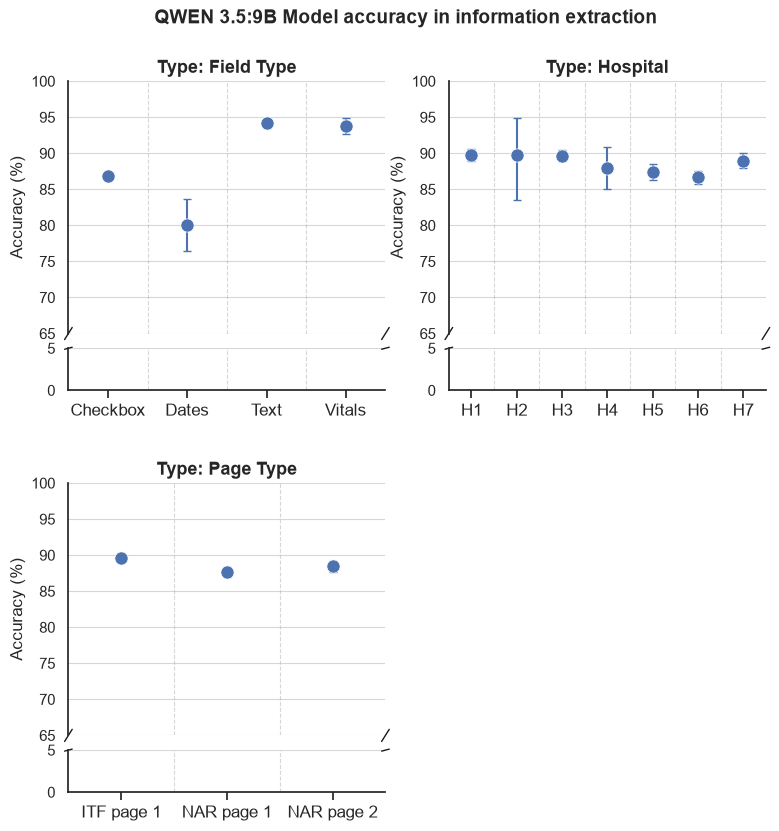

In [425]:
sns.set_theme(style="white", context="notebook")
POINT_COLOR = sns.color_palette("deep")[0]
GRIDLINE_COLOR = "#b0b0b0"


def _plot_broken_panel(fig, outer_cell, sub, xtick_fontsize, axis_label_fontsize,
                        title_fontsize, title, low_max=65, high_min=65, high_max=100,
                        high_tick_step=5):
    inner_gs = outer_cell.subgridspec(2, 1, height_ratios=[6, 1], hspace=0.1)
    ax_top = fig.add_subplot(inner_gs[0, 0])
    ax_bottom = fig.add_subplot(inner_gs[1, 0], sharex=ax_top)

    ax_top.set_ylim(high_min, high_max)
    ax_top.set_autoscaley_on(False)
    ax_bottom.set_ylim(0, low_max)
    ax_bottom.set_autoscaley_on(False)
    ax_top.set_ylabel("Accuracy (%)")

    x_pos = np.arange(len(sub))
    errors = np.vstack([
        sub["median"] - sub["lower_95"],
        sub["upper_95"] - sub["median"],
    ])

    # Vertical separator lines placed BETWEEN categories (at midpoints)
    midpoints = x_pos[:-1] + 0.5
    for ax in (ax_top, ax_bottom):
        for x in midpoints:
            ax.axvline(x, color=GRIDLINE_COLOR, linestyle="--", linewidth=0.8,
                       alpha=0.5, zorder=0)
        ax.set_xlim(x_pos[0] - 0.5, x_pos[-1] + 0.5)
        # Re-enable horizontal (y-axis) gridlines, matching the faint style
        ax.grid(axis="y", color=GRIDLINE_COLOR, linestyle="-", linewidth=0.8,
                alpha=0.5, zorder=0)
        ax.set_axisbelow(True)  # keep gridlines behind data points

    for ax in (ax_top, ax_bottom):
        sns.scatterplot(
            x=x_pos, y=sub["median"],
            color=POINT_COLOR, s=90, ax=ax, zorder=3,
            edgecolor="white", linewidth=0.5, legend=False,
        )
        ax.errorbar(
            x_pos, sub["median"],
            yerr=errors, fmt="none",
            ecolor=POINT_COLOR, elinewidth=1.5, capsize=3, zorder=2,
        )

    ax_top.set_yticks(np.arange(high_min, high_max + 1, high_tick_step))
    ax_bottom.set_yticks([0, low_max])

    ax_top.spines["bottom"].set_visible(False)
    ax_bottom.spines["top"].set_visible(False)
    ax_top.tick_params(labelbottom=False, bottom=False)
    ax_bottom.xaxis.tick_bottom()

    d = 0.012
    kwargs = dict(transform=ax_top.transAxes, color="k", clip_on=False, linewidth=1)
    ax_top.plot((-d, +d), (-d * 2, +d * 2), **kwargs)
    ax_top.plot((1 - d, 1 + d), (-d * 2, +d * 2), **kwargs)
    kwargs.update(transform=ax_bottom.transAxes)
    ax_bottom.plot((-d, +d), (1 - d * 2, 1 + d * 2), **kwargs)
    ax_bottom.plot((1 - d, 1 + d), (1 - d * 2, 1 + d * 2), **kwargs)

    ax_bottom.set_xticks(x_pos)
    ax_bottom.set_xticklabels(sub["variable"], rotation=0, ha="center",
                               fontsize=xtick_fontsize)
    ax_top.tick_params(axis="y", labelsize=axis_label_fontsize)
    ax_bottom.tick_params(axis="y", labelsize=axis_label_fontsize)
    ax_top.set_title(title, fontsize=title_fontsize, fontweight="bold")
    ax_bottom.set_ylabel("")

    sns.despine(ax=ax_top, bottom=True)
    sns.despine(ax=ax_bottom)

    return ax_top, ax_bottom


def plot_ci_grid_by_type(df: pd.DataFrame, figsize=(9, 9), save_path=None,
                          xtick_fontsize=12, axis_label_fontsize=11,
                          title_fontsize=13, low_max=5, high_min=65, high_max=100,
                          high_tick_step=5):
    """
    2x2 grid of panels, one per unique value of 'Type'. Each panel plots
    'variable' on the x-axis, 'median' as a point, and an error bar spanning
    ['lower_95', 'upper_95'], with a broken y-axis: [0, low_max] compressed,
    [low_max, high_max] shown with ticks every `high_tick_step` units.
    """
    types = sorted(df["Type"].unique())
    if len(types) > 4:
        raise ValueError(
            f"plot_ci_grid_by_type supports up to 4 Type values for a 2x2 grid, "
            f"got {len(types)}: {types}"
        )

    fig = plt.figure(figsize=figsize)
    outer_gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.2, top=0.9)

    for i in range(4):
        row, col = divmod(i, 2)
        if i >= len(types):
            ax = fig.add_subplot(outer_gs[row, col])
            ax.axis("off")
            continue

        type_val = types[i]
        sub = df[df["Type"] == type_val].copy()
        _plot_broken_panel(
            fig, outer_gs[row, col], sub,
            xtick_fontsize=xtick_fontsize,
            axis_label_fontsize=axis_label_fontsize,
            title_fontsize=title_fontsize,
            title=f"Type: {type_val}",
            low_max=low_max, high_min=high_min, high_max=high_max,
            high_tick_step=high_tick_step,
        )

    fig.suptitle("QWEN 3.5:9B Model accuracy in information extraction",
                 fontsize=14, fontweight="bold")

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig

# Usage:
fig = plot_ci_grid_by_type(model_eval_stats, save_path="Figure 1.png")